In [1]:
import torch
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# create dataset
n_pts = 100
centers = [[-0.5, 0.5], [0.5, -0.5]]
X, y = datasets.make_blobs(n_samples=n_pts, centers=centers, random_state=42, cluster_std=0.4)
X = torch.Tensor(X)
y = torch.Tensor(y)
y = y.view(n_pts, 1)

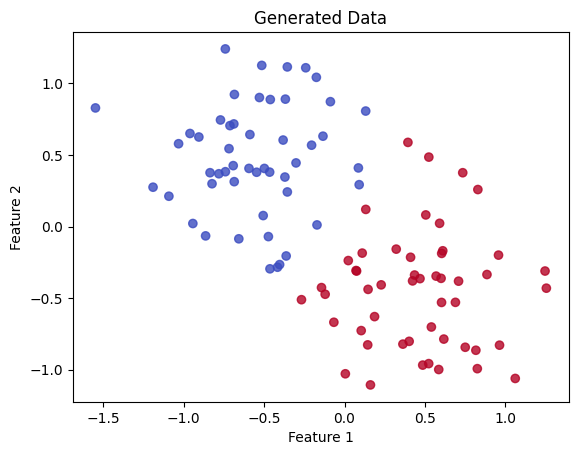

In [18]:
# visualize the data
import matplotlib.pyplot as plt

def visualize_data(X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.8)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Generated Data")
    plt.show()

visualize_data(X, y)


In [19]:
def train(model, X, y, epochs=100, lr=0.01):
    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X)
        
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    print("Training complete.")


class PerceptronModel(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = torch.nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.fc(x)


In [20]:
model = PerceptronModel(input_dim=2)
train(model, X, y)

Epoch [10/100], Loss: 0.7000
Epoch [20/100], Loss: 0.6887
Epoch [30/100], Loss: 0.6778
Epoch [40/100], Loss: 0.6672
Epoch [50/100], Loss: 0.6569
Epoch [60/100], Loss: 0.6469
Epoch [70/100], Loss: 0.6371
Epoch [80/100], Loss: 0.6277
Epoch [90/100], Loss: 0.6185
Epoch [100/100], Loss: 0.6096
Training complete.


In [22]:
# test on new data
from hmac import new


def test(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        preds = torch.round(torch.sigmoid(outputs))
        accuracy = (preds.eq(y).sum() / float(y.size(0))).item() 
        print(f"Test Accuracy: {accuracy:.4f}")

test(model, X, y)

# for new data
def test_on_new_data(model, new_data):
    model.eval()
    with torch.no_grad():
        outputs = model(new_data)
        preds = torch.round(torch.sigmoid(outputs))
        return preds

new_data = torch.Tensor([[0.2, 0.3], [-0.3, -0.2]])
predictions = test_on_new_data(model, new_data)
print("Predictions for new data:")
print(predictions)


Test Accuracy: 0.7100
Predictions for new data:
tensor([[0.],
        [1.]])
